# **Brazilian E-Commerce Data Analysis (Olist Dataset)**

### **Objective:**

This project analyzes real-world e-commerce data from Olist to understand customer behavior,
payment patterns, delivery performance, and revenue distribution.

### **The goal is to identify key business insights that impact:**

  Customer satisfaction
  Revenue generation
  Delivery efficiency
  Customer purchasing behavior

### **Key Focus Areas:**

  Customer segmentation and VIP identification
  Payment method analysis
  Delivery time impact on reviews
  Revenue and spending patterns



In [131]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path
path = "/content/drive/MyDrive/olist_data/"

# Load datasets
customers = pd.read_csv(path + "olist_customers_dataset.csv")
orders = pd.read_csv(path + "olist_orders_dataset.csv")
items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
df = orders.merge(customers, on="customer_id") \
           .merge(items, on="order_id") \
           .merge(payments, on="order_id") \
           .merge(reviews, on="order_id")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [133]:
# 1. Convert ALL date columns properly
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")


# 2. Feature Engineering: Delivery Time
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days


# 3. Missing Value Handling
df["review_score_filled"] = df["review_score"].fillna(df["review_score"].median())

# Customer behavior flag
df["has_review"] = df["review_score"].notnull()


# 4. Additional Quality Fix: Delivery time missing values
df = df.dropna(subset=["delivery_time"])


# 5. Data Validation
print(" Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

 Dataset shape: (114858, 31)

Missing values:
 order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date          1
order_delivered_customer_date         0
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                     

Missing values in critical variables were handled selectively to preserve analytical integrity.

In [134]:
# Extract month
df["month"] = df["order_purchase_timestamp"].dt.month

# Customer total value
customer_value = df.groupby("customer_unique_id")["payment_value"].sum()

# Define VIP threshold
vip_threshold = customer_value.quantile(0.9)

# Identify VIP customers
vip_customers = customer_value[customer_value >= vip_threshold]


# PRINT RESULTS
print("VIP threshold:", vip_threshold)
print("Number of VIP customers:", vip_customers.shape[0])
print(vip_customers.sort_values(ascending=False).head(10))

VIP threshold: 403.2390000000001
Number of VIP customers: 9276
customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
0f5ac8d5c31de21d2f25e24be15bbffb     19342.26
Name: payment_value, dtype: float64


Derived features such as delivery time and customer lifetime value were created to uncover deeper behavioral patterns.

### **Exploratory Data Analysis (EDA)**
Monthly Revenue Trend

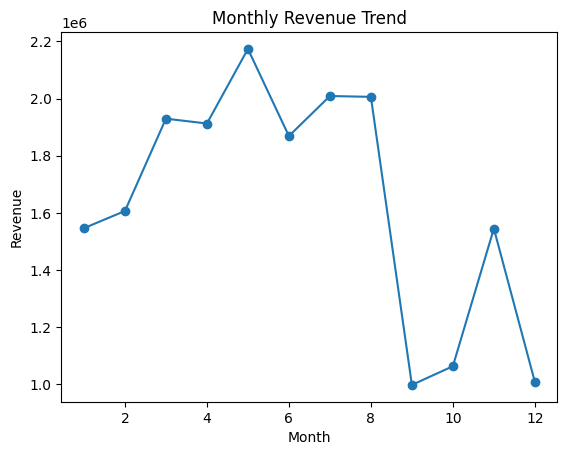

In [135]:
monthly_sales = df.groupby("month")["payment_value"].sum()

plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Payment Method Analysis

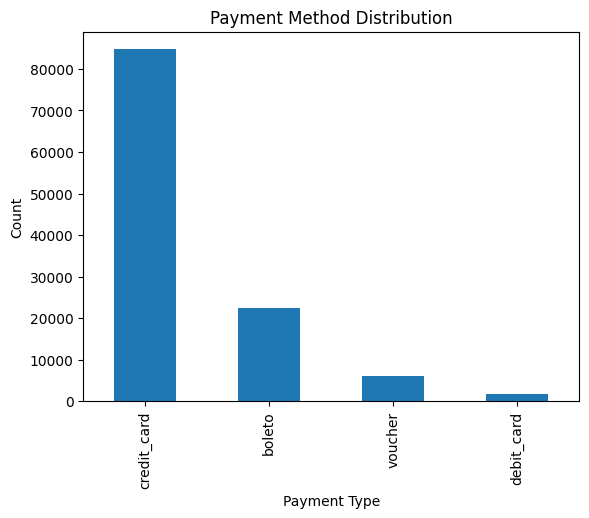

In [136]:
df["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

Delivery Impact on Reviews

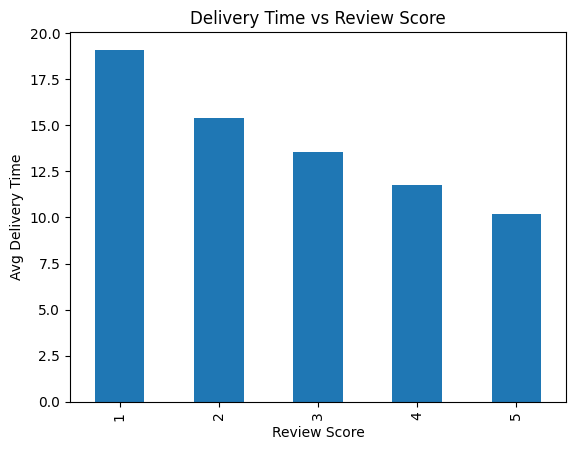

In [137]:
df.groupby("review_score")["delivery_time"].mean().plot(kind="bar")
plt.title("Delivery Time vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Avg Delivery Time")
plt.show()

Customer Value Distribution

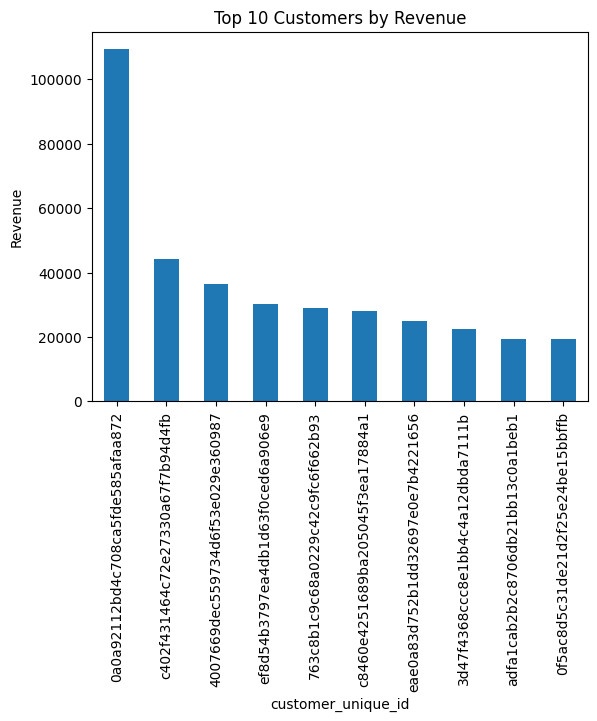

In [138]:
customer_value.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

Spending Distribution

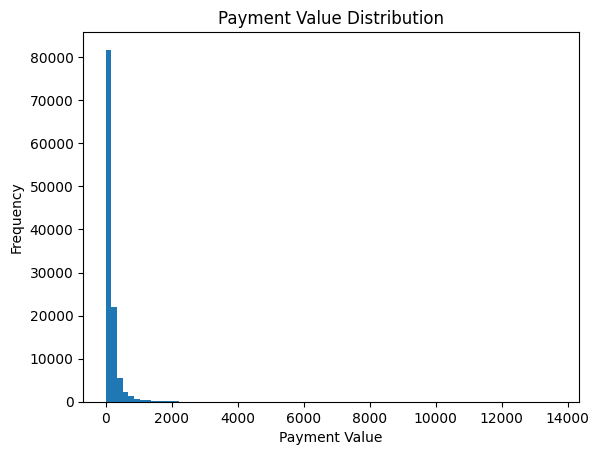

In [139]:
df["payment_value"].plot(kind="hist", bins=80)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.show()

Customer Review Behavior

In [142]:
low_review = df[df["review_score"] <= 2]
high_review = df[df["review_score"] >= 4]

print("Low review avg:", low_review["payment_value"].mean())
print("High review avg:", high_review["payment_value"].mean())


Low review avg: 224.28861021331608
High review avg: 161.4024680522956


## **Advanced Analysis**
Correlation Analysis

In [144]:
df[["payment_value", "delivery_time", "review_score"]].corr()

,payment_value,delivery_time,review_score
payment_value,1.000000,0.060637,-0.081003
delivery_time,0.060637,1.000000,-0.302582
review_score,-0.081003,-0.302582,1.000000


In [141]:
engagement = df.groupby("customer_unique_id")["order_id"].nunique()

revenue = df.groupby("customer_unique_id")["payment_value"].sum()

print(engagement.corr(revenue))

0.08401887531437485


Crosstab Analysis

In [145]:
pd.crosstab(df["payment_type"], df["review_score"])

review_score,1,2,3,4,5
payment_type,,,,,
boleto,2561,725,1948,4379,12724
credit_card,9715,2867,7046,16295,48809
debit_card,148,53,124,305,1024
voucher,694,254,532,1171,3484


Outlier Investigation

In [125]:
high_value_orders = df[df["payment_value"] > df["payment_value"].quantile(0.95)]
high_value_orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,review_score_filled,has_review,month
74,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,46740,...,c52b2e7eca1856a268a36a9df72a6150,3,NaN,Pensei que a cinta seria mais larga.\r\nÉ muit...,2018-01-18,2018-01-22 17:08:37,9.0,3,True,1
75,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,46740,...,c52b2e7eca1856a268a36a9df72a6150,3,NaN,Pensei que a cinta seria mais larga.\r\nÉ muit...,2018-01-18,2018-01-22 17:08:37,9.0,3,True,1
105,6b860b35691d486e45dc98e3514ec5f6,fee181bf648906d1c57f84f216976286,delivered,2017-12-08 09:42:43,2017-12-09 02:49:54,2017-12-11 15:19:04,2017-12-19 18:43:35,2018-01-03,4754e3b66497719a91b36268ed9c5718,13760,...,894b525b6e447029ee870124c0175c63,5,NaN,NaN,2017-12-20,2018-01-02 12:19:41,11.0,5,True,12
114,f169bd689fb8b32ccd62df9050aebc0b,82f0b75bb50fcb30711e5277e36b3983,delivered,2018-04-22 23:23:18,2018-04-24 19:24:14,2018-04-27 13:46:00,2018-04-30 17:57:25,2018-05-07,4a8c8f751984985cd49f74249da95aae,8485,...,792972abcdad4e7ac40f11946afabc17,5,Excelente,Tudo conforme o combinado!! Entrega antes do p...,2018-05-01,2018-05-01 22:05:41,7.0,5,True,4
125,bb7c5cf4dff9994daeab7c8ee9d287aa,9a4900710ff76d73cb3a0d152e73adf0,delivered,2018-03-01 22:14:26,2018-03-02 22:08:51,2018-03-05 17:32:31,2018-03-09 14:48:21,2018-03-26,97f104e8e54ef4147d17fc1536a1482c,97502,...,149788d9206ef38930eea0c0a79f9bc9,4,NaN,NaN,2018-03-10,2018-03-11 03:05:57,7.0,4,True,3


Percentile Analysis

In [146]:
# Percentiles of customer spending
percentiles = df["payment_value"].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
percentiles


,payment_value
0.25,60.72
0.50,108.00
0.75,188.69
0.90,335.73
0.95,508.84


Cohort Analysis

In [147]:
# Create cohort (first purchase month)
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

cohort = df.groupby("customer_unique_id")["purchase_month"].min().reset_index()
cohort.columns = ["customer_unique_id", "cohort_month"]

df = df.merge(cohort, on="customer_unique_id")

# Retention behavior
cohort_data = df.groupby(["cohort_month", "purchase_month"])["customer_unique_id"].nunique()
cohort_data = cohort_data.unstack(0)

cohort_data

cohort_month,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,...,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
purchase_month,,,,,,,,,,,,,,,,,,,,,
2016-10,264.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,NaN,1.0,708.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,NaN,NaN,2.0,1618.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,NaN,NaN,2.0,3.0,2484.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-04,1.0,NaN,1.0,5.0,11.0,2243.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,NaN,NaN,3.0,2.0,9.0,14.0,3424.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,NaN,NaN,1.0,7.0,10.0,5.0,16.0,3013.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-07,1.0,NaN,3.0,2.0,9.0,4.0,16.0,15.0,3722.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ratio & Derived Metrics

In [148]:
# Revenue per customer
revenue_per_customer=df.groupby("customer_unique_id")["payment_value"].sum().mean()

# Orders per customer
orders_per_customer = df.groupby("customer_unique_id")["order_id"].nunique().mean()

# Revenue per order (FIXED)
revenue_per_order = df.groupby("order_id")["payment_value"].sum().mean()

print("Revenue per customer:", revenue_per_customer)
print("Orders per customer:", orders_per_customer)
print("Revenue per order:", revenue_per_order)


Revenue per customer: 212.06859474728307
Orders per customer: 1.033174486803519
Revenue per order: 205.2592252867086


Time-Based Patterns

In [149]:
# Day of week analysis
df["day_of_week"] = df["order_purchase_timestamp"].dt.day_name()

df.groupby("day_of_week")["payment_value"].sum().sort_values()


,payment_value
day_of_week,
Saturday,2085400.37
Sunday,2206719.65
Friday,2936128.90
Thursday,2994984.51
Wednesday,3010707.90
Monday,3195280.62
Tuesday,3240564.35
